Load Data

In [1]:
import pandas as pd

df = pd.read_csv("/content/hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,01-01-2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,01-01-2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,01-01-2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,01-01-2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Data Exploration

In [2]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nStatistics:\n", df.describe())

Shape: (17379, 17)

Columns:
 Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

Missing values:
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Statistics:
           instant        season            yr          mnth            hr  \
count  17379.0000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    8690.0000      2.501640      0.502561      6.537775     11.546752   
std     5017.0295      1.106918      0.500008      3.438776      6.914405   
min        1.0000      1.000000      0.000000      1.000000      0.000000   
25%     4345.5000      2.000000      0.000000      4.00

Feature Engineering


In [3]:
# Weekend feature
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x in [0,6] else 0)

# Peak hours (7-9 AM, 5-7 PM)
df['peak_hours'] = df['hr'].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,is_weekend,peak_hours
0,1,01-01-2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,1,0
1,2,01-01-2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,1,0
2,3,01-01-2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,1,0
3,4,01-01-2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,1,0
4,5,01-01-2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,1,0


Data Preprocessing

In [4]:
# Drop irrelevant columns
df = df.drop(['instant', 'dteday', 'casual', 'registered'], axis=1)

# Features & Target
X = df.drop('cnt', axis=1)
y = df['cnt']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train Models

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Models
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=200, random_state=42)
gb = GradientBoostingRegressor(random_state=42)

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

Predictions

In [6]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

Evaluation

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def evaluate(y_test, pred, name):
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name} RMSE:", rmse)
    print(f"{name} R2:", r2)
    print("------------------------")

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, gb_pred, "Gradient Boosting")

Linear Regression RMSE: 117.66558360329392
Linear Regression R2: 0.56276615460341
------------------------
Random Forest RMSE: 41.230386898677054
Random Forest R2: 0.946315404346021
------------------------
Gradient Boosting RMSE: 63.547726411745785
Gradient Boosting R2: 0.8724692539378845
------------------------


Model Comparison Table

In [8]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]
})

results.sort_values(by="R2", ascending=False)

,Model,RMSE,R2
1,Random Forest,41.230387,0.946315
2,Gradient Boosting,63.547726,0.872469
0,Linear Regression,117.665584,0.562766


Visualization

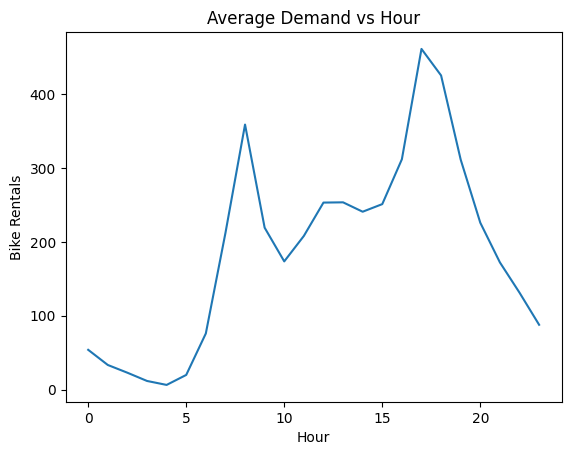

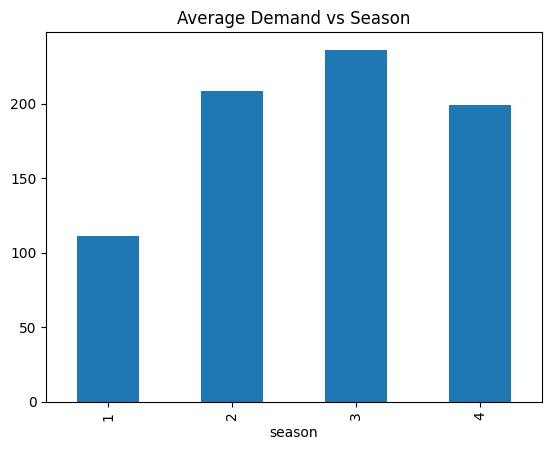

In [9]:
import matplotlib.pyplot as plt

# Demand vs Hour
df.groupby('hr')['cnt'].mean().plot(kind='line')
plt.title("Average Demand vs Hour")
plt.xlabel("Hour")
plt.ylabel("Bike Rentals")
plt.show()

# Demand vs Season
df.groupby('season')['cnt'].mean().plot(kind='bar')
plt.title("Average Demand vs Season")
plt.show()

Actual vs Predicted

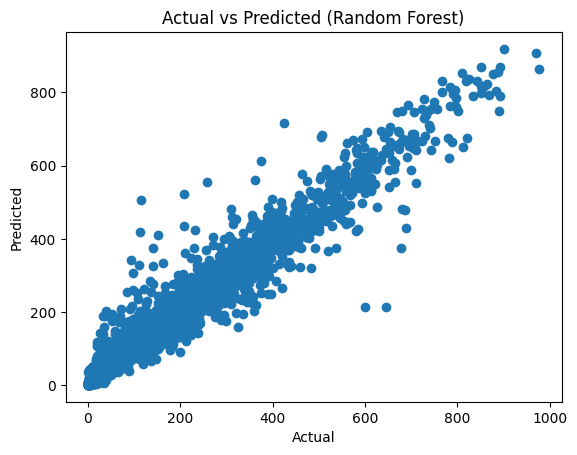

In [10]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

Among all models, Random Forest achieved the best performance with an RMSE of 41.23 and an R² score of 0.946. This indicates that the model can explain approximately 94.6% of the variance in bike rental demand. Tree-based models outperform linear regression because they effectively capture non-linear relationships and feature interactions, such as peak-hour demand and seasonal variations. Time-based features like hour, season, and working day significantly influence demand patterns, making them crucial for accurate predictions.